In [ ]:
import networkx as nx
from causallearn.graph.GraphNode import GraphNode
from causallearn.graph.GeneralGraph import GeneralGraph
from causallearn.utils.DAG2CPDAG import dag2cpdag
import matplotlib.pyplot as plt
from causallearn.graph.Endpoint import Endpoint
from networkx.drawing.nx_pydot import graphviz_layout


def nx_to_causallearn_graph(nx_dag):
    # Convert a NetworkX directed graph (DAG) into a causal-learn GeneralGraph

    # Create GraphNode objects for each node in the NetworkX graph snd Initialise causal-learn graph with these nodes
    nodes = {n: GraphNode(str(n)) for n in nx_dag.nodes()}
    graph = GeneralGraph(list(nodes.values()))
    
    # Add directed edges to the causal-learn graph
    for u, v in nx_dag.edges():
        graph.add_directed_edge(nodes[u], nodes[v])
    
    return graph


# Define a example DAG in NetworkX
dag = nx.DiGraph()
edges = [('A', 'B'), ('A', 'C'), ('A', 'D'), ('D', 'C'), ('B', 'E'), ('E', 'C'), ('B', 'D')]
dag.add_edges_from(edges)

# Convert to causal-learn graph format
cl_graph = nx_to_causallearn_graph(dag)

# Convert DAG to CPDAG
cpdag = dag2cpdag(cl_graph)

# Print CPDAG edges for inspection
print("CPDAG edges:")
for edge in cpdag.get_graph_edges():
    print(edge)

CPDAG edges:
A --- B
A --> C
A --- D
B --- D
B --- E
D --> C
E --> C


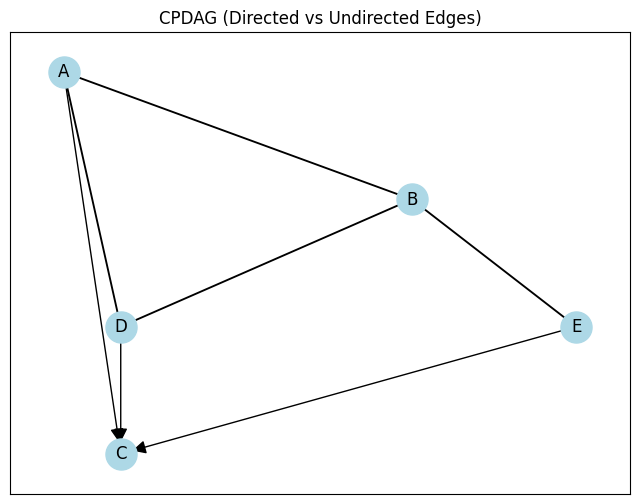

In [ ]:
def cpdag_to_nx(cpdag):
    """
    Convert a causal-learn CPDAG into two NetworkX graphs:
    one directed and one undirected
    """
    
    G_dir = nx.DiGraph()
    G_undir = nx.Graph()
    
    # Iterate through CPDAG edges and classify them
    for edge in cpdag.get_graph_edges():
        n1 = edge.get_node1().get_name()
        n2 = edge.get_node2().get_name()
        
        end1 = edge.get_endpoint1()
        end2 = edge.get_endpoint2()
        
        # Case 1: n1 → n2
        if end1 == Endpoint.TAIL and end2 == Endpoint.ARROW:
            G_dir.add_edge(n1, n2)
        
        # Case 2: n2 → n1
        elif end1 == Endpoint.ARROW and end2 == Endpoint.TAIL:
            G_dir.add_edge(n2, n1)
        
        # Case 3: undirected edge (no clear orientation)
        else:
            G_undir.add_edge(n1, n2)
    
    return G_dir, G_undir


# Convert CPDAG into directed and undirected NetworkX graphs
G_dir, G_undir = cpdag_to_nx(cpdag)

# Build a layout graph and add all nodes
G_layout = nx.DiGraph()
G_layout.add_nodes_from(G_dir.nodes())
G_layout.add_nodes_from(G_undir.nodes())

# add all edges (directed is 1, undirected is 2)
G_layout.add_edges_from(G_dir.edges())
G_layout.add_edges_from([(u, v) for u, v in G_undir.edges()])
G_layout.add_edges_from([(v, u) for u, v in G_undir.edges()])


# Initialise plot
plt.figure(figsize=(8, 6))

#draw directed and undirected edges
pos = graphviz_layout(G_layout, prog='dot')
nx.draw_networkx_edges(
    G_undir,
    pos,
    edgelist=list(G_undir.edges()),
    width=1.35
)
nx.draw_networkx_edges(
    G_dir,
    pos,
    edgelist=list(G_dir.edges()),
    arrows=True,
    arrowstyle='-|>',
    arrowsize=20,
    width=1,
    connectionstyle='arc3,rad=0.0'
)

# Draw nodes and labels
nx.draw_networkx_nodes(G_layout, pos, node_size=500, node_color="lightblue")
nx.draw_networkx_labels(G_layout, pos)

# Final plot formatting
plt.title("CPDAG (Directed vs Undirected Edges)")
plt.show()

In [12]:
from utils import download_data
import pandas as pd

download_data()

data_all = pd.read_csv("ihdp_data.csv")
data = data_all.drop(columns=['y_factual', 'y_cfactual', 'mu0', 'mu1'])
treatment = data[data.iloc[:,0]].drop(columns='treatment')
control = data[data.iloc[:, 0] == 0].drop(columns='treatment')

In [13]:
control

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25
1,-1.736945,-1.802002,0.383828,2.244320,-0.629189,1.295216,0,0,0,1,...,1,1,1,1,0,0,0,0,0,0
2,-0.807451,-0.202946,-0.360898,-0.879606,0.808706,-0.526556,0,0,0,1,...,1,0,1,1,0,0,0,0,0,0
3,0.390083,0.596582,-1.850350,-0.879606,-0.004017,-0.857787,0,0,0,0,...,1,0,1,1,0,0,0,0,0,0
4,-1.045229,-0.602710,0.011465,0.161703,0.683672,-0.360940,1,0,0,0,...,1,1,1,1,0,0,0,0,0,0
5,0.467901,-0.202946,-0.733261,0.161703,0.058500,1.957678,1,0,0,1,...,1,1,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
741,-0.331896,0.596582,-0.360898,0.161703,0.371086,1.460832,1,1,1,0,...,1,0,1,0,0,0,0,0,0,0
742,-0.007654,-0.202946,-0.360898,0.161703,-0.316603,1.792063,0,0,1,0,...,1,0,1,0,0,0,0,0,0,0
744,1.181234,0.196818,-1.477987,0.161703,0.746189,0.467138,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0
745,-0.288664,-0.202946,-1.477987,-0.879606,1.621430,0.467138,1,0,1,0,...,1,1,1,0,0,0,0,0,0,0


times = data['Time']
t1 = 6.5
t2 = 8.5
t3 = 17.5
t4 = 19.5
mask_1 = (times > t4) | (times < t1)
mask_2 = ((times >= t3) & (times <= t4)) | ((times >= t1) & (times <= t2))
mask_3 = (times > t2) & (times < t3)
result = np.zeros_like(times)
result[mask_1] = 1
result[mask_2] = 2
result[mask_3] = 3
data['Time'] = result
print("Time")
#bin time
time_bin = [0.5, 1.5, 2.5, 3.5]
labels = ['Night', 'Twilight', 'Day']
binned_time = pd.cut(data['Time'], bins=time_bin, labels=labels, right=False)
data['Time'] = binned_time
for i in range(len(time_bin) - 1):
    count = np.sum(binned_time == labels[i])
    print(f"[{time_bin[i]:.2f}-{time_bin[i+1]:.2f}]: {count}")
print("Temp")
#bin temp
temp_bin = [-100, 3, 12, 22, 32, 100]
labels = ['Freezing', 'Cold', 'Normal', 'Warm', 'Hot']
binned_temp = pd.cut(data['Temp'], bins=temp_bin, labels=labels, right=False)
data['Temp'] = binned_temp
for i in range(len(temp_bin) - 1):
    count = np.sum(binned_temp == labels[i])
    print(f"[{temp_bin[i]:.2f}-{temp_bin[i+1]:.2f}]: {count}")
print("DewP")
#bin dewp
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
8/25


dewp_bin = [-100, -3, 6, 14, 23, 100]
labels = ['Extreme Dry', 'Dry', 'Normal', 'Humid', 'Oppresive']
binned_dewp = pd.cut(data['DewP'], bins=dewp_bin, labels=labels, right=False)
data['DewP'] = binned_dewp
for i in range(len(dewp_bin) - 1):
    count = np.sum(binned_dewp == labels[i])
    print(f"[{dewp_bin[i]:.2f}-{dewp_bin[i+1]:.2f}]: {count}")
print("RH")
#bin rh
rh_bin = [0, 40, 60, 80, 1000]
labels = ['Dry', 'Normal', 'Humid', 'Very Humid']
binned_rh = pd.cut(data['RH'], bins=rh_bin, labels=labels, right=False)
data['RH'] = binned_rh
for i in range(len(rh_bin) - 1):
    count = np.sum(binned_rh == labels[i])
    print(f"[{rh_bin[i]:.2f}-{rh_bin[i+1]:.2f}]: {count}")
print("Rain")
#bin rain
rain_bin = [0, 0.0001, 1, 100]
labels = ['No Rain', 'Light Rain', 'Heavy Rain']
binned_rain = pd.cut(data['Rain'], bins=rain_bin, labels=labels, right=False)
data['Rain'] = binned_rain
for i in range(len(rain_bin) - 1):
    count = np.sum(binned_rain == labels[i])
    print(f"[{rain_bin[i]:.2f}-{rain_bin[i+1]:.2f}]: {count}")
print("Clouds")
#bin clouds
clouds_bin = [0, 10, 80, 1000]
labels = ['Clear', 'Partly', 'Overcast']
binned_clouds = pd.cut(data['Clouds'], bins=clouds_bin, labels=labels, right=False)
data['Clouds'] = binned_clouds
for i in range(len(clouds_bin) - 1):
    count = np.sum(binned_clouds == labels[i])
    print(f"[{clouds_bin[i]:.2f}-{clouds_bin[i+1]:.2f}]: {count}")
print("Wind")
#bin wind
wind_bin = [0, 8, 19, 100]
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
9/25


labels = ['No wind', 'Light wind', 'Very windy']
binned_wind = pd.cut(data['Wind'], bins=wind_bin, labels=labels, right=False)
data['Wind'] = binned_wind
for i in range(len(wind_bin) - 1):
    count = np.sum(binned_wind == labels[i])
    print(f"[{wind_bin[i]:.2f}-{wind_bin[i+1]:.2f}]: {count}")
print("Pressure")
#bin pressure
pressure_bin = [0, 995, 1015, 10000]
labels = ['Low Pressure', 'Normal', 'High Pressure']
binned_pressure = pd.cut(data['Pressure'], bins=pressure_bin, labels=labels, right=False)
data['Pressure'] = binned_pressure
for i in range(len(pressure_bin) - 1):
    count = np.sum(binned_pressure == labels[i])
    print(f"[{pressure_bin[i]:.2f}-{pressure_bin[i+1]:.2f}]: {count}")
data.head()
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
10/25


Time
[0.50-1.50]: 4625
[1.50-2.50]: 1603
[2.50-3.50]: 3772
Temp
[-100.00-3.00]: 93
[3.00-12.00]: 1599
[12.00-22.00]: 3952
[22.00-32.00]: 3935
[32.00-100.00]: 421
DewP
[-100.00--3.00]: 413
[-3.00-6.00]: 1624
[6.00-14.00]: 3130
[14.00-23.00]: 3901
[23.00-100.00]: 932
RH
[0.00-40.00]: 1231
[40.00-60.00]: 2116
[60.00-80.00]: 2861
[80.00-1000.00]: 3792
Rain
[0.00-0.00]: 8787
[0.00-1.00]: 920
[1.00-100.00]: 293
Clouds
[0.00-10.00]: 3351
[10.00-80.00]: 3428
[80.00-1000.00]: 3221
Wind
[0.00-8.00]: 3814
[8.00-19.00]: 5100
[19.00-100.00]: 1086
Pressure
[0.00-995.00]: 2452
[995.00-1015.00]: 5632
[1015.00-10000.00]: 1916
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
11/25


Time
Temp
DewP
RH
Rain
Clouds
Wind
Pressure
0
Day
Warm
Humid
Very Humid
Light Rain
Overcast
Light wind
High Pressure
1
Night
Normal
Normal
Humid
No Rain
Overcast
Light wind
High Pressure
2
Day
Normal
Humid
Very Humid
No Rain
Overcast
No wind
Low Pressure
3
Twilight
Normal
Humid
Very Humid
No Rain
Overcast
Light wind
High Pressure
4
Night
Normal
Normal
Very Humid
No Rain
Partly
No wind
Normal
#Hill Climb Search
scoring_method_hc = BicScore(data)
hc = HillClimbSearch(data)
best_model_hc = hc.estimate(scoring_method=scoring_method_hc)
# Print and compare BIC scores
bic_hc = BicScore(data).score(best_model_hc)
print(f"BIC Score - Hill Climb Search: {bic_hc}")
#HC
print("Edges:", list(best_model_hc.edges()))
model_hc = BayesianNetwork(best_model_hc.edges())
G_hc = nx.Graph()
G_hc.add_edges_from(model_hc.edges())
pos_hc = nx.nx_agraph.graphviz_layout(G_hc,prog="dot")
nx.draw(G_hc, pos_hc, with_labels=True, node_color='lightblue')
plt.title("Hill Climb Search Network")
plt.show()
  0%|          | 0/1000000 [00:00<?, ?it/s]
BIC Score - Hill Climb Search: -72324.41333504753
Edges: [('Time', 'RH'), ('Time', 'Temp'), ('Time', 'Wind'), ('Time', 'Clouds'), ('Temp', 'DewP'), ('DewP', 'Pressure'), ('RH', 
'DewP'), ('RH', 'Temp'), ('RH', 'Rain'), ('Rain', 'Wind'), ('Clouds', 'RH'), ('Clouds', 'Rain'), ('Wind', 'Pressure')]
Out[181…
In [183…
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
12/25


fixed_edges = [('Temp','RH'),('Time','RH'),('Time','Temp')]
#fixed_edges = []
best_model = best_model_hc
pos = pos_hc
graph = G_hc.copy()
dag = nx.DiGraph()
dag.add_edges_from(list(best_model.edges()))
In [203…
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
13/25


equivalent_dags, count = get_markov_equivalents_with_fixed_edges(dag, fixed_edges)
sets = [set(vector.edges) for vector in equivalent_dags]
print(list(set.intersection(*sets)))
fixed_edges = fixed_edges + list(set.intersection(*sets))
i = 1
remaining_dags = []
for dag in equivalent_dags:
    if all(edge in dag.edges() for edge in fixed_edges):
            print(f"DAG {i}:", dag.edges())
            remaining_dags.append(list(dag.edges))
            i += 1
common_elements = set(remaining_dags[0]).intersection(*remaining_dags[1:])
fixed_edges = common_elements
nx.draw_networkx_edges(graph, pos, edgelist=[e for e in graph.edges if e not in fixed_edges and (e[1], e[0]) not in fixed_edge
                       edge_color='black', width=1)
directed_graph = nx.DiGraph(graph)
nx.draw_networkx_edges(directed_graph, pos, edgelist=fixed_edges, edge_color='black', width=1, arrows=True, arrowsize=30)
nx.draw_networkx_nodes(graph, pos, node_size=900, node_color="lightblue")
nx.draw_networkx_labels(graph, pos, font_size=15)
plt.axis('off')
plt.show()
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
14/25


Number of Markov equivalent DAGs (without fixed edges): 18
All Equivalent DAGs (edge lists):
DAG 1: [('Time', 'RH'), ('Time', 'Temp'), ('Time', 'Wind'), ('Time', 'Clouds'), ('RH', 'DewP'), ('RH', 'Temp'), ('RH', 'Rain'), 
('RH', 'Clouds'), ('Temp', 'DewP'), ('Wind', 'Pressure'), ('Clouds', 'Rain'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
DAG 2: [('Time', 'RH'), ('Time', 'Temp'), ('Time', 'Wind'), ('Time', 'Clouds'), ('RH', 'DewP'), ('RH', 'Temp'), ('RH', 'Rain'), 
('Temp', 'DewP'), ('Wind', 'Pressure'), ('Clouds', 'RH'), ('Clouds', 'Rain'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
DAG 3: [('Time', 'RH'), ('Time', 'Temp'), ('Time', 'Wind'), ('Time', 'Clouds'), ('RH', 'DewP'), ('RH', 'Rain'), ('RH', 'Cloud
s'), ('Temp', 'RH'), ('Temp', 'DewP'), ('Wind', 'Pressure'), ('Clouds', 'Rain'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
DAG 4: [('Time', 'RH'), ('Time', 'Temp'), ('Time', 'Wind'), ('RH', 'DewP'), ('RH', 'Temp'), ('RH', 'Rain'), ('Temp', 'DewP'), 
('Wind', 'Pressure'), ('Clouds', 'Time'), ('Clouds', 'RH'), ('Clouds', 'Rain'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
DAG 5: [('Time', 'RH'), ('Time', 'Wind'), ('Time', 'Clouds'), ('RH', 'DewP'), ('RH', 'Rain'), ('RH', 'Clouds'), ('Temp', 'Tim
e'), ('Temp', 'RH'), ('Temp', 'DewP'), ('Wind', 'Pressure'), ('Clouds', 'Rain'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
DAG 6: [('Time', 'Temp'), ('Time', 'Wind'), ('Time', 'Clouds'), ('RH', 'Time'), ('RH', 'DewP'), ('RH', 'Temp'), ('RH', 'Rain'), 
('RH', 'Clouds'), ('Temp', 'DewP'), ('Wind', 'Pressure'), ('Clouds', 'Rain'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
DAG 7: [('Time', 'Temp'), ('Time', 'Wind'), ('RH', 'Time'), ('RH', 'DewP'), ('RH', 'Temp'), ('RH', 'Rain'), ('RH', 'Clouds'), 
('Temp', 'DewP'), ('Wind', 'Pressure'), ('Clouds', 'Time'), ('Clouds', 'Rain'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
DAG 8: [('Time', 'Temp'), ('Time', 'Wind'), ('RH', 'Time'), ('RH', 'DewP'), ('RH', 'Temp'), ('RH', 'Rain'), ('RH', 'Clouds'), 
('Temp', 'DewP'), ('Wind', 'Pressure'), ('Clouds', 'Time'), ('DewP', 'Pressure'), ('Rain', 'Wind'), ('Rain', 'Clouds')]
DAG 9: [('Time', 'Temp'), ('Time', 'Wind'), ('RH', 'Time'), ('RH', 'DewP'), ('RH', 'Temp'), ('RH', 'Rain'), ('Temp', 'DewP'), 
('Wind', 'Pressure'), ('Clouds', 'Time'), ('Clouds', 'RH'), ('Clouds', 'Rain'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
DAG 10: [('Time', 'Temp'), ('Time', 'Wind'), ('RH', 'Time'), ('RH', 'DewP'), ('RH', 'Temp'), ('RH', 'Clouds'), ('Temp', 'Dew
P'), ('Wind', 'Pressure'), ('Clouds', 'Time'), ('DewP', 'Pressure'), ('Rain', 'RH'), ('Rain', 'Wind'), ('Rain', 'Clouds')]
DAG 11: [('Time', 'Temp'), ('Time', 'Wind'), ('RH', 'Time'), ('RH', 'DewP'), ('RH', 'Temp'), ('Temp', 'DewP'), ('Wind', 'Pressu
re'), ('Clouds', 'Time'), ('Clouds', 'RH'), ('Clouds', 'Rain'), ('DewP', 'Pressure'), ('Rain', 'RH'), ('Rain', 'Wind')]
DAG 12: [('Time', 'Temp'), ('Time', 'Wind'), ('RH', 'Time'), ('RH', 'DewP'), ('RH', 'Temp'), ('Temp', 'DewP'), ('Wind', 'Pressu
re'), ('Clouds', 'Time'), ('Clouds', 'RH'), ('DewP', 'Pressure'), ('Rain', 'RH'), ('Rain', 'Wind'), ('Rain', 'Clouds')]
DAG 13: [('Time', 'Wind'), ('Time', 'Clouds'), ('RH', 'Time'), ('RH', 'DewP'), ('RH', 'Temp'), ('RH', 'Rain'), ('RH', 'Cloud
s'), ('Temp', 'Time'), ('Temp', 'DewP'), ('Wind', 'Pressure'), ('Clouds', 'Rain'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
DAG 14: [('Time', 'Wind'), ('Time', 'Clouds'), ('RH', 'Time'), ('RH', 'DewP'), ('RH', 'Temp'), ('RH', 'Rain'), ('RH', 'Cloud
s'), ('Temp', 'Time'), ('Wind', 'Pressure'), ('Clouds', 'Rain'), ('DewP', 'Temp'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
DAG 15: [('Time', 'Wind'), ('Time', 'Clouds'), ('RH', 'Time'), ('RH', 'DewP'), ('RH', 'Rain'), ('RH', 'Clouds'), ('Temp', 'Tim
e'), ('Temp', 'RH'), ('Temp', 'DewP'), ('Wind', 'Pressure'), ('Clouds', 'Rain'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
DAG 16: [('Time', 'Wind'), ('Time', 'Clouds'), ('RH', 'Time'), ('RH', 'Temp'), ('RH', 'Rain'), ('RH', 'Clouds'), ('Temp', 'Tim
e'), ('Wind', 'Pressure'), ('Clouds', 'Rain'), ('DewP', 'RH'), ('DewP', 'Temp'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
DAG 17: [('Time', 'Wind'), ('Time', 'Clouds'), ('RH', 'Time'), ('RH', 'Rain'), ('RH', 'Clouds'), ('Temp', 'Time'), ('Temp', 'R
H'), ('Temp', 'DewP'), ('Wind', 'Pressure'), ('Clouds', 'Rain'), ('DewP', 'RH'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
DAG 18: [('Time', 'Wind'), ('Time', 'Clouds'), ('RH', 'Time'), ('RH', 'Rain'), ('RH', 'Clouds'), ('Temp', 'Time'), ('Temp', 'R
H'), ('Wind', 'Pressure'), ('Clouds', 'Rain'), ('DewP', 'RH'), ('DewP', 'Temp'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
Fixed [('Temp', 'RH'), ('Time', 'RH'), ('Time', 'Temp')]: 1 possible structures.
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
15/25


Removed 17 of 18
[('Rain', 'Wind'), ('Time', 'Wind'), ('DewP', 'Pressure'), ('Wind', 'Pressure')]
DAG 1: [('Time', 'RH'), ('Time', 'Temp'), ('Time', 'Wind'), ('Time', 'Clouds'), ('RH', 'DewP'), ('RH', 'Rain'), ('RH', 'Cloud
s'), ('Temp', 'RH'), ('Temp', 'DewP'), ('Wind', 'Pressure'), ('Clouds', 'Rain'), ('DewP', 'Pressure'), ('Rain', 'Wind')]
model = BayesianNetwork([('Time', 'RH'), ('Time', 'Temp'), ('Time', 'Wind'),
                         ('Time', 'Clouds'), ('RH', 'DewP'), ('RH', 'Rain'), 
                         ('RH', 'Clouds'), ('Temp', 'RH'), ('Temp', 'DewP'), 
                         ('Wind', 'Pressure'), ('Clouds', 'Rain'), ('DewP', 'Pressure'), 
                         ('Rain', 'Wind')])
    
mle = MaximumLikelihoodEstimator(model, data)
model.fit(data, estimator=MaximumLikelihoodEstimator)
print("CPDs in the intervened model:")
In [355…
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
16/25


for cpd in model.get_cpds():
    print(f"CPD for {cpd.variable}:")
    print(cpd)
    print()
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
17/25


CPDs in the intervened model:
CPD for Time:
+----------------+--------+
| Time(Day)      | 0.3772 |
+----------------+--------+
| Time(Night)    | 0.4625 |
+----------------+--------+
| Time(Twilight) | 0.1603 |
+----------------+--------+
CPD for RH:
+----------------+---------------------+-----+----------------------+---------------------+
| Temp           | Temp(Cold)          | ... | Temp(Warm)           | Temp(Warm)          |
+----------------+---------------------+-----+----------------------+---------------------+
| Time           | Time(Day)           | ... | Time(Night)          | Time(Twilight)      |
+----------------+---------------------+-----+----------------------+---------------------+
| RH(Dry)        | 0.12080536912751678 | ... | 0.026188835286009647 | 0.11148086522462562 |
+----------------+---------------------+-----+----------------------+---------------------+
| RH(Humid)      | 0.34563758389261745 | ... | 0.25982081323225364  | 0.28618968386023297 |
+----------------+---------------------+-----+----------------------+---------------------+
| RH(Normal)     | 0.2785234899328859  | ... | 0.12611991729841487  | 0.19633943427620631 |
+----------------+---------------------+-----+----------------------+---------------------+
| RH(Very Humid) | 0.2550335570469799  | ... | 0.5878704341833219   | 0.4059900166389351  |
+----------------+---------------------+-----+----------------------+---------------------+
CPD for Temp:
+----------------+----------------------+-----------------------+----------------------+
| Time           | Time(Day)            | Time(Night)           | Time(Twilight)       |
+----------------+----------------------+-----------------------+----------------------+
| Temp(Cold)     | 0.07900318133616119  | 0.2229189189189189    | 0.1684341859014348   |
+----------------+----------------------+-----------------------+----------------------+
| Temp(Freezing) | 0.003976670201484623 | 0.010810810810810811  | 0.017467248908296942 |
+----------------+----------------------+-----------------------+----------------------+
| Temp(Hot)      | 0.08510074231177095  | 0.0073513513513513516 | 0.041172800998128506 |
+----------------+----------------------+-----------------------+----------------------+
| Temp(Normal)   | 0.33271474019088015  | 0.4451891891891892    | 0.39800374298190894  |
+----------------+----------------------+-----------------------+----------------------+
| Temp(Warm)     | 0.4992046659597031   | 0.31372972972972973   | 0.3749220212102308   |
+----------------+----------------------+-----------------------+----------------------+
CPD for Wind:
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
18/25


+------------------+------------------+-----+---------------------+---------------------+
| Rain             | Rain(Heavy Rain) | ... | Rain(No Rain)       | Rain(No Rain)       |
+------------------+------------------+-----+---------------------+---------------------+
| Time             | Time(Day)        | ... | Time(Night)         | Time(Twilight)      |
+------------------+------------------+-----+---------------------+---------------------+
| Wind(Light wind) | 0.568            | ... | 0.45161290322580644 | 0.5269978401727862  |
+------------------+------------------+-----+---------------------+---------------------+
| Wind(No wind)    | 0.096            | ... | 0.47343453510436434 | 0.40532757379409645 |
+------------------+------------------+-----+---------------------+---------------------+
| Wind(Very windy) | 0.336            | ... | 0.07495256166982922 | 0.06767458603311735 |
+------------------+------------------+-----+---------------------+---------------------+
CPD for Clouds:
+------------------+---------------------+-----+---------------------+---------------------+
| RH               | RH(Dry)             | ... | RH(Very Humid)      | RH(Very Humid)      |
+------------------+---------------------+-----+---------------------+---------------------+
| Time             | Time(Day)           | ... | Time(Night)         | Time(Twilight)      |
+------------------+---------------------+-----+---------------------+---------------------+
| Clouds(Clear)    | 0.6070133010882709  | ... | 0.231496062992126   | 0.15568862275449102 |
+------------------+---------------------+-----+---------------------+---------------------+
| Clouds(Overcast) | 0.1487303506650544  | ... | 0.40511811023622046 | 0.5164670658682635  |
+------------------+---------------------+-----+---------------------+---------------------+
| Clouds(Partly)   | 0.24425634824667472 | ... | 0.36338582677165354 | 0.3278443113772455  |
+------------------+---------------------+-----+---------------------+---------------------+
CPD for DewP:
+-------------------+---------------------+-----+--------------------+--------------------+
| RH                | RH(Dry)             | ... | RH(Very Humid)     | RH(Very Humid)     |
+-------------------+---------------------+-----+--------------------+--------------------+
| Temp              | Temp(Cold)          | ... | Temp(Normal)       | Temp(Warm)         |
+-------------------+---------------------+-----+--------------------+--------------------+
| DewP(Dry)         | 0.08411214953271028 | ... | 0.0                | 0.0                |
+-------------------+---------------------+-----+--------------------+--------------------+
| DewP(Extreme Dry) | 0.9158878504672897  | ... | 0.0                | 0.0                |
+-------------------+---------------------+-----+--------------------+--------------------+
| DewP(Humid)       | 0.0                 | ... | 0.6458452722063037 | 0.4973544973544973 |
+-------------------+---------------------+-----+--------------------+--------------------+
| DewP(Normal)      | 0.0                 | ... | 0.3541547277936963 | 0.0                |
+-------------------+---------------------+-----+--------------------+--------------------+
| DewP(Oppresive)   | 0.0                 | ... | 0.0                | 0.5026455026455027 |
+-------------------+---------------------+-----+--------------------+--------------------+
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
19/25


CPD for Rain:
+------------------+---------------+-----+---------------------+----------------------+
| Clouds           | Clouds(Clear) | ... | Clouds(Partly)      | Clouds(Partly)       |
+------------------+---------------+-----+---------------------+----------------------+
| RH               | RH(Dry)       | ... | RH(Normal)          | RH(Very Humid)       |
+------------------+---------------+-----+---------------------+----------------------+
| Rain(Heavy Rain) | 0.0           | ... | 0.00398406374501992 | 0.018561484918793503 |
+------------------+---------------+-----+---------------------+----------------------+
| Rain(Light Rain) | 0.0           | ... | 0.01593625498007968 | 0.10208816705336426  |
+------------------+---------------+-----+---------------------+----------------------+
| Rain(No Rain)    | 1.0           | ... | 0.9800796812749004  | 0.8793503480278422   |
+------------------+---------------+-----+---------------------+----------------------+
CPD for Pressure:
+-------------------------+--------------------+-----+---------------------+---------------------+
| DewP                    | DewP(Dry)          | ... | DewP(Oppresive)     | DewP(Oppresive)     |
+-------------------------+--------------------+-----+---------------------+---------------------+
| Wind                    | Wind(Light wind)   | ... | Wind(No wind)       | Wind(Very windy)    |
+-------------------------+--------------------+-----+---------------------+---------------------+
| Pressure(High Pressure) | 0.2596026490066225 | ... | 0.42565597667638483 | 0.14814814814814814 |
+-------------------------+--------------------+-----+---------------------+---------------------+
| Pressure(Low Pressure)  | 0.1576158940397351 | ... | 0.12244897959183673 | 0.16666666666666666 |
+-------------------------+--------------------+-----+---------------------+---------------------+
| Pressure(Normal)        | 0.5827814569536424 | ... | 0.4518950437317784  | 0.6851851851851852  |
+-------------------------+--------------------+-----+---------------------+---------------------+
prob = 'DewP'
var1 = 'RH'
var2 = 'Temp'
state1 = 2
state2 = 4
def remove_incoming_edges(model, node):
    model_in = model.copy()
    incoming_edges = [edge for edge in model.edges() if edge[1] == node]
    model_in.remove_edges_from(incoming_edges)
In [363…
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
20/25


    return model_in
def print_cpd_table(query_result):
    variables = query_result.variables
    state_names = query_result.state_names
    prob_values = query_result.values.flatten() 
    state_combinations = list(itertools.product(*[state_names[var] for var in variables]))
    header = " | ".join(variables + ["Probability"])
    print(header)
    print("-" * len(header))
    for idx, state_combination in enumerate(state_combinations):
        row = " | ".join(str(state) for state in state_combination) + f" | {prob_values[idx]:.4f}"
        print(row)
do = remove_incoming_edges(model, var)
G = nx.DiGraph()
G.add_edges_from(do.edges())
pos = nx.nx_agraph.graphviz_layout(G,prog="dot")
nx.draw(G, pos, with_labels=True, node_color='lightblue')
plt.title("Graph")
plt.show()
cardinality = 2
state_names1 = data[var1].cat.categories  
state_names1 = state_names1.tolist()
state_names2 = data[var2].cat.categories  
state_names2 = state_names2.tolist()
#marginal
print("marginal")
n = len(data[prob])
prob_names = data[prob].cat.categories  
prob_names = prob_names.tolist()
for names in prob_names:
    marg = np.sum(data[prob]==names)/n
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
21/25


    print(f"P({prob}={names} = {marg:.4f})")
print()
print()
#normal single conditional
print("conditional")
inference = VariableElimination(model)
query_result = inference.query(variables=[prob], evidence={var1: state_names1[state1]})
print(f"P({prob} | {var1} = {state_names1[state1]}):")
print_cpd_table(query_result)
print()
print()
#normal double conditional
print("conditional")
inference = VariableElimination(model)
query_result = inference.query(variables=[prob], evidence={var1: state_names1[state1], var2: state_names2[state2]})
print(f"P({prob} | {var1} = {state_names1[state1]}, {var2} = {state_names2[state2]}):")
print_cpd_table(query_result)
print()
print()
#intervention conditional
#print("intervention")
#inference = VariableElimination(do)
#query_result = inference.query(variables=[prob], evidence={var: state_names[state]})
#print(f"P({prob} | do({var} = {state_names[state]})):")
#print_cpd_table(query_result)
#confirm
causal_inference = CausalInference(model)
query_result = causal_inference.query(variables=[prob], evidence={var1: state_names1[state1]}, do={var2: state_names2[state2]}
print(f"P({prob} | do({var2} = {state_names2[state2]}), {var1} = {state_names1[state1]}):")
print(query_result)
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
22/25


24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
23/25


marginal
P(DewP=Extreme Dry = 0.0413)
P(DewP=Dry = 0.1624)
P(DewP=Normal = 0.3130)
P(DewP=Humid = 0.3901)
P(DewP=Oppresive = 0.0932)
conditional
P(DewP | RH = Humid):
DewP | Probability
------------------
Dry | 0.1576
Extreme Dry | 0.0084
Humid | 0.4212
Normal | 0.3226
Oppresive | 0.0902
conditional
P(DewP | RH = Humid, Temp = Hot):
DewP | Probability
------------------
Dry | 0.0000
Extreme Dry | 0.0000
Humid | 0.0000
Normal | 0.0000
Oppresive | 1.0000
  0%|          | 0/3 [00:00<?, ?it/s]
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
24/25


P(DewP | do(Temp = Hot), RH = Humid):
+-------------------+-------------+
| DewP              |   phi(DewP) |
+===================+=============+
| DewP(Dry)         |      0.0374 |
+-------------------+-------------+
| DewP(Extreme Dry) |      0.0140 |
+-------------------+-------------+
| DewP(Humid)       |      0.7430 |
+-------------------+-------------+
| DewP(Normal)      |      0.1708 |
+-------------------+-------------+
| DewP(Oppresive)   |      0.0346 |
+-------------------+-------------+
24/03/2025, 23:56
Untitled
file:///C:/Users/gmedw/Downloads/Untitled.html
25/25
